# Environment Setup & Data Loading:

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
import os

# Suppress technical warnings
warnings.filterwarnings("ignore")
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
%matplotlib inline

# Loading dataset
df = pd.read_csv('Data Churn.csv')

# Plotting Style
sns.set_theme(style="white")

# Data Inspection

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning & Statistics

In [18]:
# Cleaning process
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop('customerID', axis=1, inplace=True, errors='ignore')

# Statistical Summaries
print("Numerical Summary:")
df.describe().T


Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80


In [19]:

print("\nCategorical Summary:")
display(df.describe(include='object').T)


Categorical Summary:


,count,unique,top,freq
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095
TechSupport,7043,3,No,3473


# Visual Exploratory Data Analysis

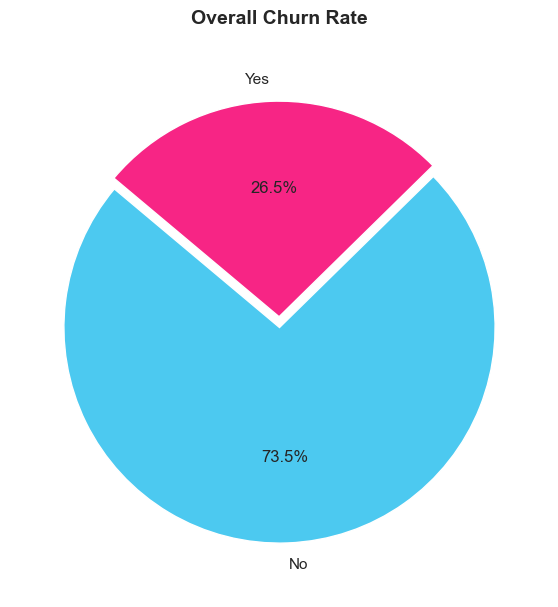

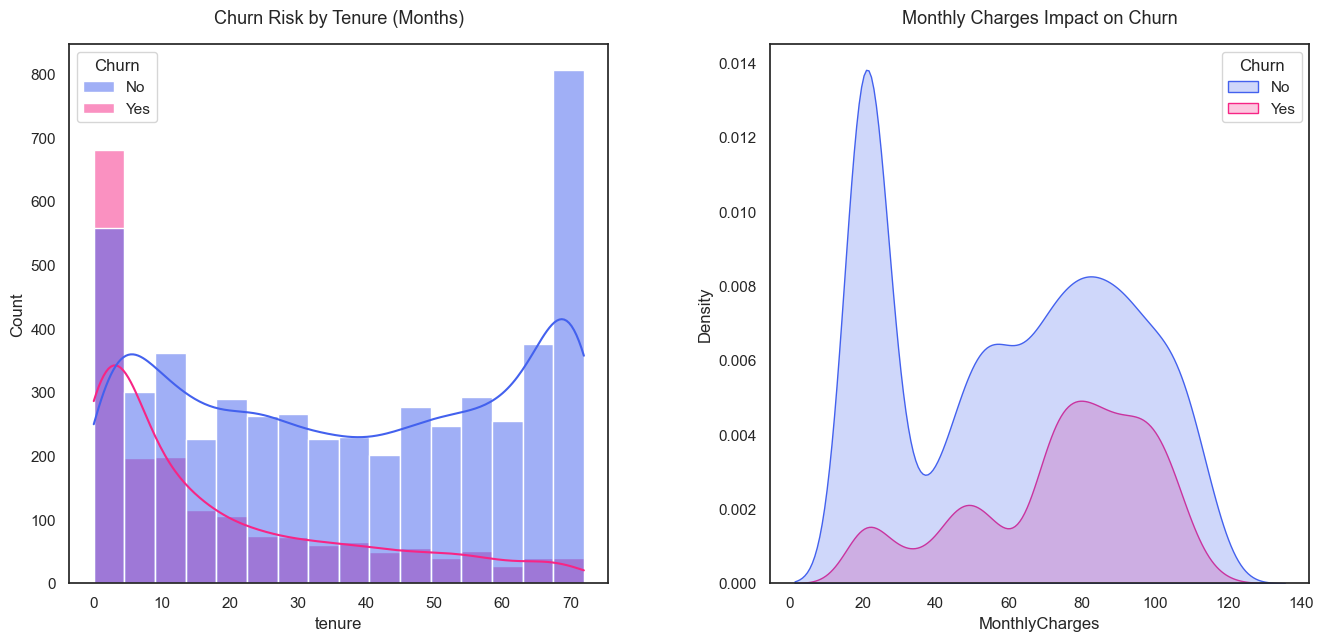

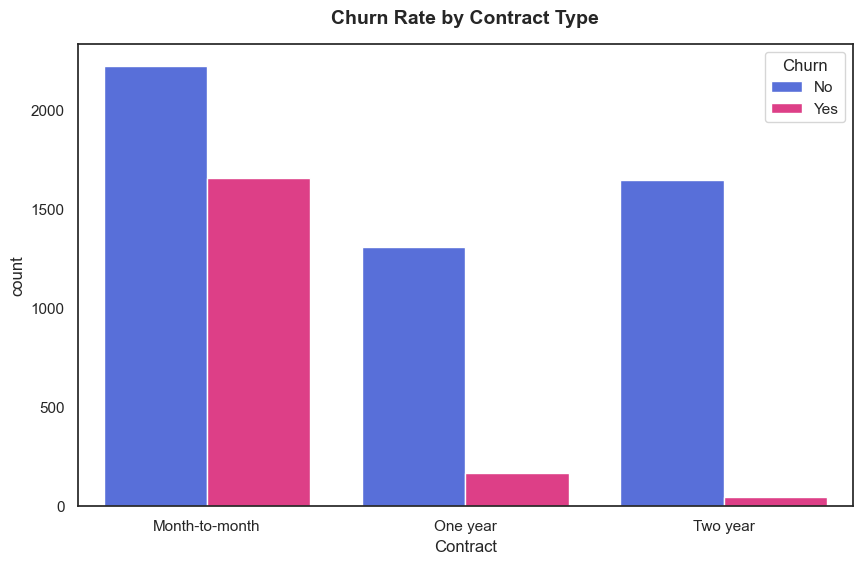


[Insights Summary]
1. Critical Period: Most churn happens in the first 12 months (Early Lifecycle).
2. Price Sensitivity: Churn peaks at high monthly bills (>$70).
3. Contract Factor: Month-to-month contracts are the primary source of customer loss.


In [20]:
# --- Professional Visual Analysis ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Target Distribution (The Overview)
plt.figure(figsize=(7, 7))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=["#4cc9f0", "#f72585"], explode=(0, 0.05))
plt.title('Overall Churn Rate', fontsize=14, weight='bold', pad=25)
plt.ylabel('')
plt.show()

# 2. Loyalty and Financial Analysis (The Drivers)
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
plt.subplots_adjust(wspace=0.3) 

# Tenure Plot
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette=["#4361ee", "#f72585"], ax=ax[0])
ax[0].set_title('Churn Risk by Tenure (Months)', fontsize=13, pad=15)

# Monthly Charges Plot
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette=["#4361ee", "#f72585"], ax=ax[1])
ax[1].set_title('Monthly Charges Impact on Churn', fontsize=13, pad=15)
plt.show()

# 3. Contract Analysis (The Business Logic) - "هذه الرسمة هي الأهم"
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette=["#4361ee", "#f72585"])
plt.title('Churn Rate by Contract Type', fontsize=14, weight='bold', pad=15)
plt.show()

# Summary Print
print("\n[Insights Summary]")
print("1. Critical Period: Most churn happens in the first 12 months (Early Lifecycle).")
print("2. Price Sensitivity: Churn peaks at high monthly bills (>$70).")
print("3. Contract Factor: Month-to-month contracts are the primary source of customer loss.")

# Advanced Preprocessing & Correlation

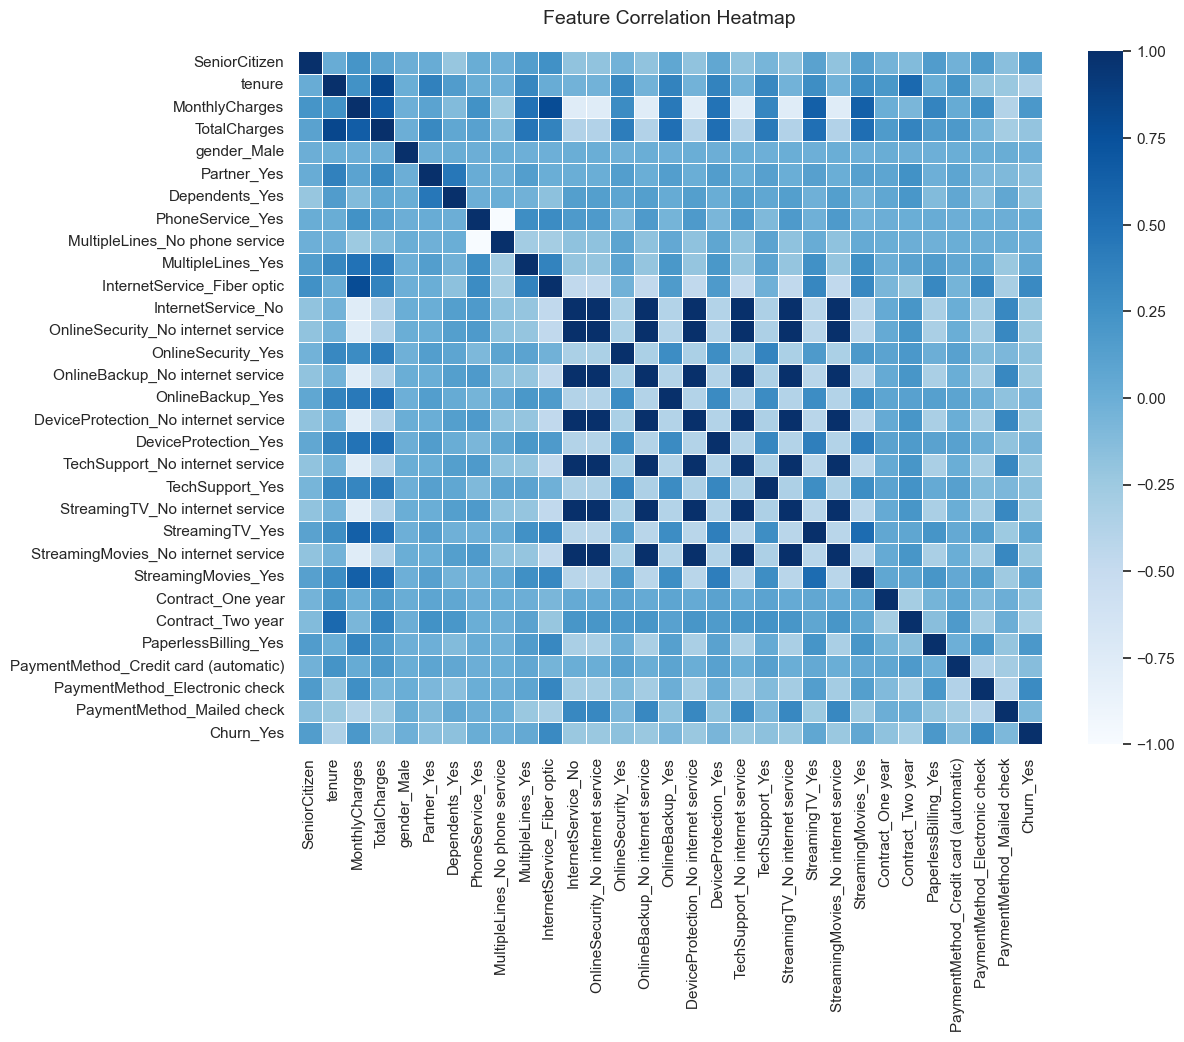

Dropped Features: ['MultipleLines_No phone service', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']


In [21]:
df_ml = pd.get_dummies(df, drop_first=True)
corr_matrix = df_ml.corr()

# High-contrast professional heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap='Blues', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, pad=20)
plt.show()

# Drop features with correlation > 0.85
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"Dropped Features: {to_drop}")
df_ml = df_ml.drop(columns=to_drop)

# Balancing (SMOTE) and Predictive Modeling

In [22]:
# Splitting Data
X = df_ml.drop('Churn_Yes', axis=1) if 'Churn_Yes' in df_ml.columns else df_ml.drop('Churn', axis=1)
y = df_ml['Churn_Yes'] if 'Churn_Yes' in df_ml.columns else df_ml['Churn']

# Applying SMOTE for Class Balance
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Training Optimized Random Forest
rf_final = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
rf_final.fit(X_train, y_train)

# Evaluation Results
y_pred = rf_final.predict(X_test)
print(f"Prediction Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("-" * 40)
print("Classification Report:\n", classification_report(y_test, y_pred))

Prediction Accuracy Score: 86.09%
----------------------------------------
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.86      0.86      1021
        True       0.86      0.87      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



# Final Performance Visualization

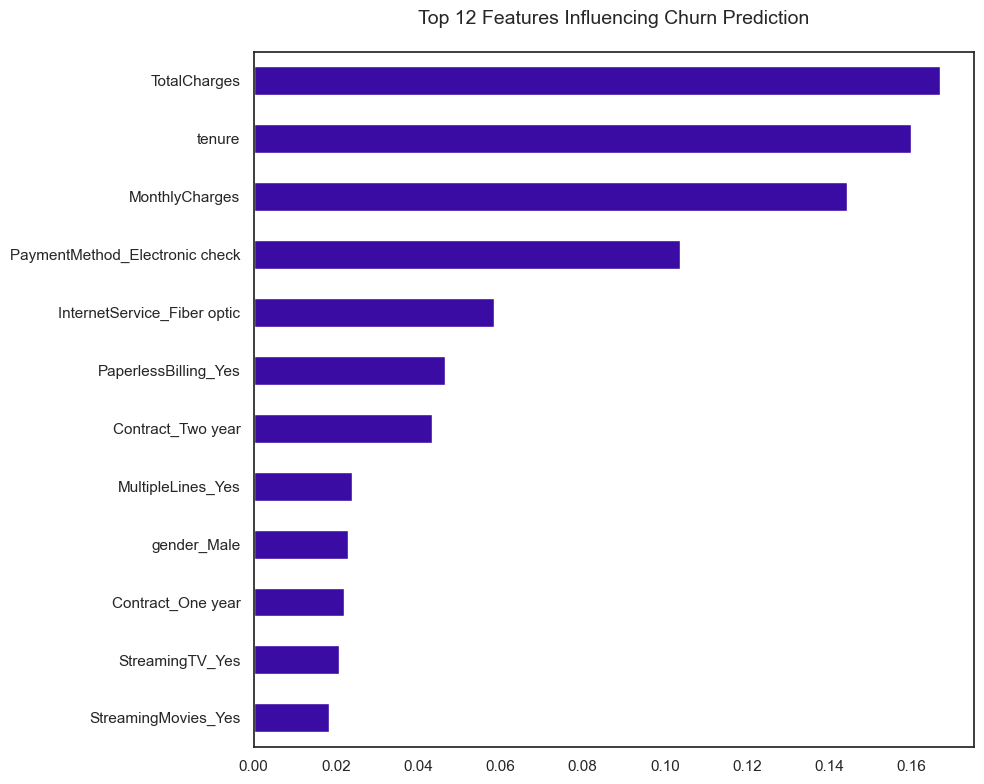

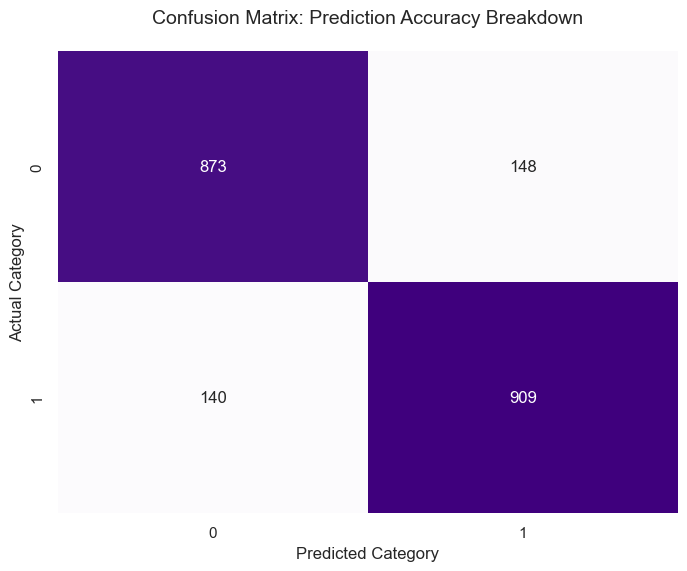

In [23]:
# 1. Prediction Drivers
plt.figure(figsize=(10, 8))
importances = pd.Series(rf_final.feature_importances_, index=X.columns)
importances.nlargest(12).plot(kind='barh', color='#3a0ca3')
plt.title('Top 12 Features Influencing Churn Prediction', fontsize=14, pad=20)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 2. Performance Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix: Prediction Accuracy Breakdown', fontsize=14, pad=20)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

### Final Business Insights & Recommendations
1. **Focus on Early Retention:** Churn risk is extremely high in the first 12 months. Incentives should be offered to new customers.
2. **Contract Upgrades:** Month-to-month contracts are high-risk. Offer discounts for moving customers to 1 or 2-year contracts.
3. **Price Sensitivity:** High Monthly Charges (> $70) lead to churn. Review pricing strategies for high-value customers.
4. **Tech Support:** Customers without technical support churn more often. Bundling tech support with basic packages is highly recommended.